In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder,LabelEncoder,StandardScaler)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from xgboost import XGBRegressor

In [2]:
path = kagglehub.dataset_download(
    "atomicd/retail-store-inventory-and-demand-forecasting"
)
print("Dataset Path :", path)

Dataset Path : C:\Users\Muskan\.cache\kagglehub\datasets\atomicd\retail-store-inventory-and-demand-forecasting\versions\8


In [3]:
os.listdir(path)

['sales_data.csv']

In [4]:
file_path = os.path.join(path, "sales_data.csv")
df = pd.read_csv(file_path)

In [5]:
print("Shape of Dataset :", df.shape)
print("\nFirst 5 Rows")
display(df.head())

Shape of Dataset : (76000, 16)

First 5 Rows


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [7]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])
corr = numeric_cols.corr()
print(corr["Demand"].sort_values(ascending=False))

Demand                1.000000
Units Sold            0.833421
Units Ordered         0.511963
Promotion             0.282537
Discount              0.224723
Inventory Level       0.126618
Competitor Pricing   -0.023036
Price                -0.023461
Epidemic             -0.363661
Name: Demand, dtype: float64


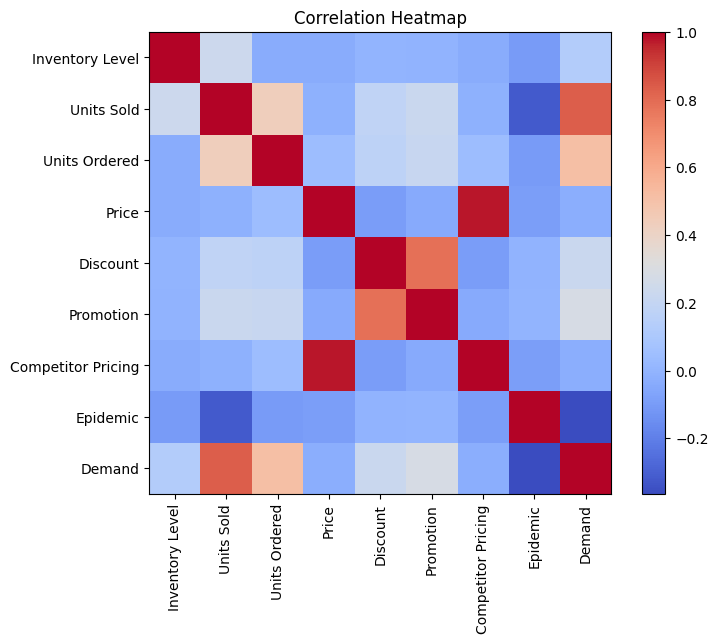

In [10]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Is_Weekend"] = df["Day_of_Week"].apply(
    lambda x: 1 if x >= 5 else 0
)
df["Price_Difference"] = (
    df["Competitor Pricing"] - df["Price"]
)
df["Inventory_to_Sales"] = (
    df["Inventory Level"] / (df["Units Sold"] + 1)
)

In [12]:
df.drop("Date", axis=1, inplace=True)
print(df.shape)

(76000, 22)


In [13]:
X = df.drop("Demand", axis=1)
y = df["Demand"]
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (76000, 21)
Target Shape   : (76000,)


In [14]:
categ_cols = X.select_dtypes(include=["object"]).columns
print(categ_cols)

Index(['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition',
       'Seasonality'],
      dtype='object')


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categ",
            OneHotEncoder(handle_unknown="ignore"),
            categ_cols
        )
    ],
    remainder="passthrough"
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (60800, 21)
Testing Shape  : (15200, 21)


In [17]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)

(60800, 57)
(15200, 57)


In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)
rf_pred = rf.predict(X_test_processed)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("-"*40)
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest
----------------------------------------
MAE : 12.5
RMSE: 16.61
R²  : 0.8751


In [19]:
gb = GradientBoostingRegressor(
    random_state=42
)
gb.fit(X_train_processed, y_train)
gb_pred = gb.predict(X_test_processed)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)
print("Gradient Boosting")
print("-"*40)
print("MAE :", round(gb_mae,2))
print("RMSE:", round(gb_rmse,2))
print("R²  :", round(gb_r2,4))

Gradient Boosting
----------------------------------------
MAE : 13.7
RMSE: 17.71
R²  : 0.858


In [20]:
et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
et.fit(X_train_processed, y_train)
et_pred = et.predict(X_test_processed)
et_mae = mean_absolute_error(y_test, et_pred)
et_rmse = np.sqrt(mean_squared_error(y_test, et_pred))
et_r2 = r2_score(y_test, et_pred)
print("Extra Trees")
print("-"*40)
print("MAE :", round(et_mae,2))
print("RMSE:", round(et_rmse,2))
print("R²  :", round(et_r2,4))

Extra Trees
----------------------------------------
MAE : 12.32
RMSE: 16.39
R²  : 0.8784


In [21]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_processed, y_train)
xgb_pred = xgb.predict(X_test_processed)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print("XGBoost")
print("-"*40)
print("MAE :", round(xgb_mae,2))
print("RMSE:", round(xgb_rmse,2))
print("R²  :", round(xgb_r2,4))

XGBoost
----------------------------------------
MAE : 10.79
RMSE: 14.33
R²  : 0.907


In [22]:
results = pd.DataFrame({
    "Model":[
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "XGBoost"
    ],
    "MAE":[
        rf_mae,
        gb_mae,
        et_mae,
        xgb_mae
    ],
    "RMSE":[
        rf_rmse,
        gb_rmse,
        et_rmse,
        xgb_rmse
    ],
    "R2 Score":[
        rf_r2,
        gb_r2,
        et_r2,
        xgb_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results

,Model,MAE,RMSE,R2 Score
3,XGBoost,10.788712,14.330344,0.907015
2,Extra Trees,12.322299,16.387697,0.878399
0,Random Forest,12.503419,16.607238,0.875120
1,Gradient Boosting,13.701368,17.711411,0.857962


In [23]:
from sklearn.model_selection import RandomizedSearchCV
params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [5, 7, 9],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    verbose=1,
    n_jobs=-1
)
random_search.fit(X_train_processed, y_train)
best_model = random_search.best_estimator_
print("Best Parameters")
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [24]:
pred = best_model.predict(X_test_processed)
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)
print("="*40)
print("Final Tuned XGBoost")
print("="*40)
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Final Tuned XGBoost
MAE      : 10.17
MSE      : 183.25
RMSE     : 13.54
R² Score : 0.9170


In [25]:
feature_names = preprocessor.get_feature_names_out()
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(15)

,Feature,Importance
43,remainder__Units Sold,0.282849
49,remainder__Epidemic,0.104580
28,categ__Category_Groceries,0.079286
44,remainder__Units Ordered,0.077176
47,remainder__Promotion,0.058112
56,remainder__Inventory_to_Sales,0.043874
27,categ__Category_Furniture,0.043399
25,categ__Category_Clothing,0.039566
40,categ__Seasonality_Summer,0.022147
29,categ__Category_Toys,0.011751


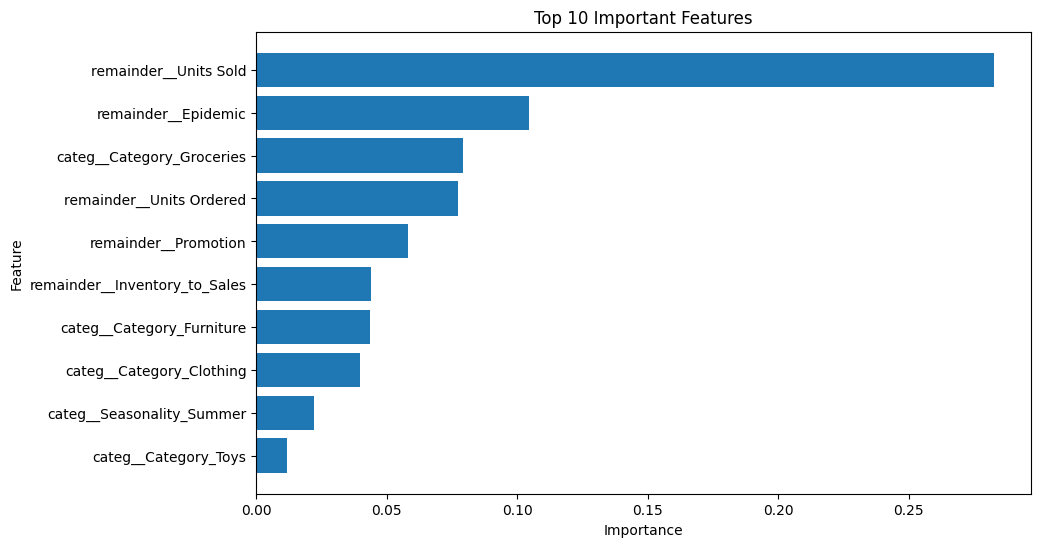

In [26]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

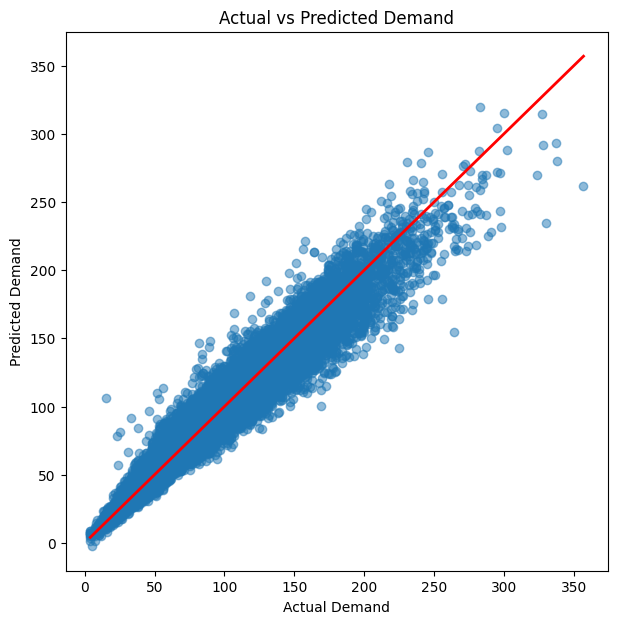

In [27]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")
plt.show()

In [29]:
joblib.dump(best_model, "retailiq_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [30]:
dropdown_values = {
    "Store ID": sorted(df["Store ID"].unique()),
    "Product ID": sorted(df["Product ID"].unique()),
    "Category": sorted(df["Category"].unique()),
    "Region": sorted(df["Region"].unique()),
    "Weather Condition": sorted(df["Weather Condition"].unique()),
    "Seasonality": sorted(df["Seasonality"].unique())
}

joblib.dump(dropdown_values, "dropdown_values.pkl")

print("Dropdown values saved successfully!")

Dropdown values saved successfully!
